# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [2]:
pip install cvxopt

  Using cached cvxopt-1.3.3-cp313-cp313-macosx_15_0_arm64.whl.metadata (43 kB)
Using cached cvxopt-1.3.3-cp313-cp313-macosx_15_0_arm64.whl (4.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
!python --version

Python 3.13.11


### Package Imports

In [12]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [ ]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)



1860    0
353     9
1333    5
905     9
1289    4
Name: label, dtype: int64

In [21]:
training_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


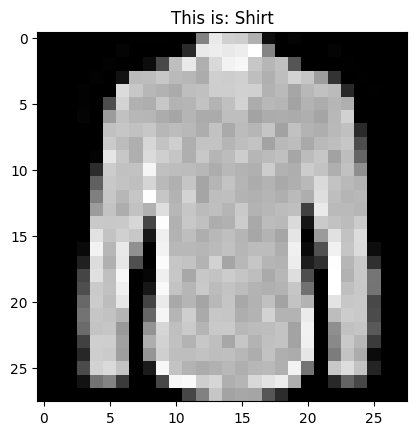

In [108]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

In [96]:
label_to_title = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [110]:
def nonlinear_kernel(X, y):
  """
  Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
  Feel free to implement either 'rbf', 'poly' or 'sigmoid'
  WARNING: 'rbf' can be quite slow and there exist some approximation methods
  Parameters
  ----------
  X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

  y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
  """
  return

In [120]:
def nonlinear_kernel(X1, X2, gamma=0.01):
    """
    Computes the RBF kernel matrix between X1 and X2
    X1: shape (n1, d)
    X2: shape (n2, d)
    Returns:
        Kernel matrix of shape (n1, n2)
    """
    
    # Compute squared norms
    X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
    X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
    
    # Compute squared Euclidean distance
    sq_dist = X1_sq + X2_sq - 2 * np.dot(X1, X2.T)
    
    # Apply RBF formula
    K = np.exp(-gamma * sq_dist)
    
    return K

In [127]:
# --------------------------------------------------
# Select two classes for binary classification
# --------------------------------------------------

class1 = 7   # Sneaker
class2 = 9   # Ankle boot

# Filter training data
mask = (train_samples_labels == class1) | (train_samples_labels == class2)

X_train_binary = X_train_binary / 255.0
X_test_binary  = X_test_binary / 255.0

X_train_binary = train_samples[mask].values
y_train_binary = train_samples_labels[mask]

# Convert labels to -1 and +1
y_train_binary = np.where(y_train_binary == class1, -1, 1)

print("Unique labels:", np.unique(y_train_binary))
print("Binary training shape:", X_train_binary.shape)

Unique labels: [-1  1]
Binary training shape: (328, 784)


In [128]:
# --------------------------------------------------
# Create binary TEST dataset
# --------------------------------------------------

mask_test = (test_samples_labels == class1) | (test_samples_labels == class2)

X_test_binary = test_samples[mask_test].values
y_test_binary = test_samples_labels[mask_test]

# Convert to -1 / +1
y_test_binary = np.where(y_test_binary == class1, -1, 1)

print("Unique test labels:", np.unique(y_test_binary))
print("Binary test shape:", X_test_binary.shape)

Unique test labels: [-1  1]
Binary test shape: (56, 784)


In [133]:
K = nonlinear_kernel(X_train_binary, X_train_binary, gamma=0.005)
print("Kernel shape:", K.shape)

Kernel shape: (328, 328)


In [ ]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = C

  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization 
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.
    return self

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    return

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    return

In [134]:
class SVM(object):

    def __init__(self, kernel, C=1.0):
        self.kernel = kernel
        self.C = C
        self.alphas = None
        self.support_vectors = None
        self.support_labels = None
        self.b = None

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y).astype(float)

        N = X.shape[0]

        # Compute Kernel matrix
        K = self.kernel(X, X)

        # Build QP matrices
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(N))

        # 0 <= a_i <= C
        G = matrix(np.vstack((np.eye(N), -np.eye(N))))
        h = matrix(np.hstack((self.C * np.ones(N), np.zeros(N))))

        # Equality constraint
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        # Solve QP
        solution = solvers.qp(P, q, G, h, A, b)
        alphas = np.array(solution['x']).flatten()

        # Support vectors
        sv = alphas > 1e-5

        self.alphas = alphas[sv]
        self.support_vectors = X[sv]
        self.support_labels = y[sv]

        # Compute bias (Bishop 7.37)
        b_vals = []

        for i in range(len(self.alphas)):
            sum_term = np.sum(
                self.alphas * self.support_labels *
                self.kernel(self.support_vectors, 
                            self.support_vectors[i:i+1]).flatten()
            )
            b_vals.append(self.support_labels[i] - sum_term)

        self.b = np.mean(b_vals)

        return self


    def predict(self, X):

        X = np.asarray(X)

        K_test = self.kernel(X, self.support_vectors)

        decision = np.dot(K_test, self.alphas * self.support_labels) + self.b

        return np.sign(decision)


    def score(self, X, y):

        predictions = self.predict(X)
        return np.mean(predictions == y)

In [135]:
svm = SVM(kernel=lambda X1, X2: nonlinear_kernel(X1, X2, gamma=0.005), C=1.0)

svm.fit(X_train_binary, y_train_binary)

predictions = svm.predict(X_test_binary)

print("Test Accuracy:", svm.score(X_test_binary, y_test_binary))

Test Accuracy: 0.6071428571428571


## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [140]:
X_train = train_samples.values / 255.0
y_train = train_samples_labels

X_test = test_samples.values / 255.0
y_test = test_samples_labels

In [142]:
d = X_train.shape[1]
d  # should be 784

784

In [144]:
gamma = 1 / d
gamma

0.0012755102040816326

In [146]:
kernel = lambda X1, X2: nonlinear_kernel(X1, X2, gamma=1/X_train.shape[1])
kernel

<function __main__.<lambda>(X1, X2)>

In [137]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

class OneVsRestSVM:
    def __init__(self, kernel, C=1.0):
        self.kernel = kernel
        self.C = C
        self.models = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)

        for cls in self.classes:
            y_binary = np.where(y == cls, 1, -1)
            model = SVM(kernel=self.kernel, C=self.C)
            model.fit(X, y_binary)
            self.models[cls] = model

    def predict(self, X):
        scores = []

        for cls in self.classes:
            model = self.models[cls]
            K_test = model.kernel(X, model.support_vectors)
            decision = np.dot(K_test,
                              model.alphas * model.support_labels) + model.b
            scores.append(decision)

        scores = np.vstack(scores).T
        return self.classes[np.argmax(scores, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [138]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

from itertools import combinations

class OneVsOneSVM:
    def __init__(self, kernel, C=1.0):
        self.kernel = kernel
        self.C = C
        self.models = []
        self.pairs = []

    def fit(self, X, y):
        self.classes = np.unique(y)

        for (cls1, cls2) in combinations(self.classes, 2):
            mask = (y == cls1) | (y == cls2)
            X_pair = X[mask]
            y_pair = y[mask]

            y_binary = np.where(y_pair == cls1, 1, -1)

            model = SVM(kernel=self.kernel, C=self.C)
            model.fit(X_pair, y_binary)

            self.models.append(model)
            self.pairs.append((cls1, cls2))

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes)))

        for model, (cls1, cls2) in zip(self.models, self.pairs):
            preds = model.predict(X)

            for i, pred in enumerate(preds):
                if pred == 1:
                    votes[i, np.where(self.classes == cls1)[0][0]] += 1
                else:
                    votes[i, np.where(self.classes == cls2)[0][0]] += 1

        return self.classes[np.argmax(votes, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [147]:
ovr = OneVsRestSVM(kernel=kernel, C=1.0)
ovo = OneVsOneSVM(kernel=kernel, C=1.0)

ovr.fit(X_train, y_train)
print("OvR Accuracy:", ovr.score(X_test, y_test))

ovo.fit(X_train, y_train)
print("OvO Accuracy:", ovo.score(X_test, y_test))

OvR Accuracy: 0.785
OvO Accuracy: 0.795


## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [ ]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

In [149]:
C_values = np.logspace(-2, 3, 6)
C_values

array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])

In [150]:
C_values = np.logspace(-2, 3, 6)
results = []

for C_val in C_values:
    print("Testing C =", C_val)
    
    ovr = OneVsRestSVM(kernel=kernel, C=C_val)
    ovr.fit(X_train, y_train)
    
    acc = ovr.score(X_test, y_test)
    results.append((C_val, acc))
    
    print("Accuracy:", acc)

Testing C = 0.01
Accuracy: 0.595
Testing C = 0.1
Accuracy: 0.73
Testing C = 1.0
Accuracy: 0.785
Testing C = 10.0
Accuracy: 0.845
Testing C = 100.0
Accuracy: 0.84
Testing C = 1000.0
Accuracy: 0.815


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [ ]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
def confusion_matrix_multiclass(y_true, y_pred):
    classes = np.unique(y_true)
    K = len(classes)
    
    matrix = np.zeros((K, K), dtype=int)
    
    for true, pred in zip(y_true, y_pred):
        i = np.where(classes == true)[0][0]
        j = np.where(classes == pred)[0][0]
        matrix[i, j] += 1
        
    return matrix, classes


In [151]:
y_pred_ovr = ovr.predict(X_test)
y_pred_ovo = ovo.predict(X_test)

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

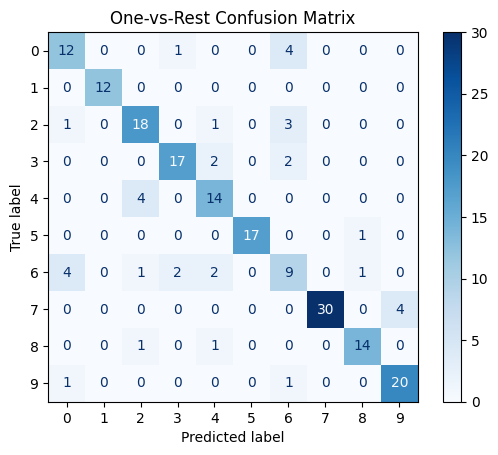

In [153]:
labels = np.unique(y_test)

cm_ovr = confusion_matrix(y_test, y_pred_ovr, labels=labels)

disp_ovr = ConfusionMatrixDisplay(confusion_matrix=cm_ovr,
                                  display_labels=labels)

disp_ovr.plot(cmap='Blues')
plt.title("One-vs-Rest Confusion Matrix")
plt.show()

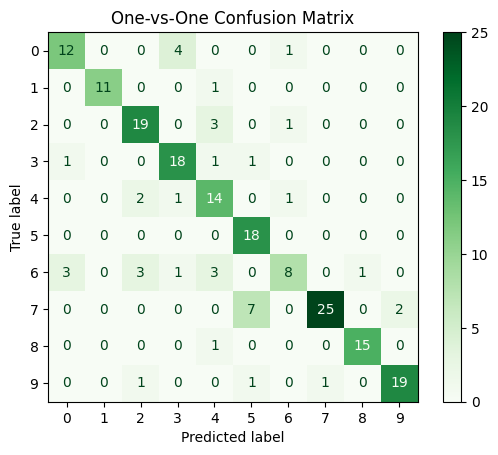

In [154]:
cm_ovo = confusion_matrix(y_test, y_pred_ovo, labels=labels)

disp_ovo = ConfusionMatrixDisplay(confusion_matrix=cm_ovo,
                                  display_labels=labels)

disp_ovo.plot(cmap='Greens')
plt.title("One-vs-One Confusion Matrix")
plt.show()

In [155]:
cm_ovr_norm = cm_ovr / cm_ovr.sum(axis=1, keepdims=True)
cm_ovo_norm = cm_ovo / cm_ovo.sum(axis=1, keepdims=True)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

The confusion matrices exhibit strong diagonal dominance, indicating high overall classification accuracy. Most errors occur between visually similar classes. For example, classes 6 and 0, and classes 7 and 9 exhibit notable confusion. The One-vs-One classifier slightly reduces several off-diagonal errors compared to One-vs-Rest, particularly for pairwise similar categories. This supports the theoretical expectation that OvO benefits from localized binary decision boundaries.

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.